# Parsing of RO-Crate for publishing
This notebook will read and RO-Crate file from galaxy, extract the provenance information as PROV-O in JSON-LD and save it into a new version of the RO-Crate.

1. read galaxy ro-crate
2. read the prospective provenance from the workflow and retrospective provenance from the workflow run into a PROV-O graph
3. extract discovery and context metadata from each dataset in the RO-Crate (from the provenance and from the datasets details)
4. save the PROV-O graph and the datasets metadata in the RO-Crate (in a provenance folder)
5. get a publishable package consisting of RO-Crate + context (a JSON-LD file)
6. get package ready to publish to Invenio RDM (latest Zenodo API)

The context metadata as JSON-LD is intended to facilitate discovery and interoperability

# Inputs

These are the RO-Crates used for testing

In [1]:
from read_provenance import *

input_folder = "./input"
# "FeS2-Analysis.rocrate.zip" # OK 
# "FeS2-Analysis-Mod_01.rocrate.zip" # OK  
# "Invocation-of-CDIF-Test-2026-04-22.rocrate.zip" # First CDIF testing RO Crate, ok some activities missing? maybe defined parameters
# "Paper_1_Pt3Sn.rocrate.zip" # OK, pending defined parameters (they are not datasets for galaxy)
# "Paper_2_Diphosphine.rocrate.zip" # OK
# "Paper_3-Au-colloids202604.rocrate.zip" # OK Corrected ROC, fail was caused by unasigned inputs
# "paper_4_Palladium-CO.rocrate.zip" # OK
# "Paper_5-LaMnO3-Catalytic-Behaviour.rocrate.zip" # OK 
# "Paper_6_100C_175C_300C.rocrate.zip" # OK
# "Paper_6-PdAl2O3_100C_175C_300C.rocrate.zip" # OK
# "Paper_7-MoOxAl2O3.rocrate.zip" # OK 
# "Paper_8-EXAFS-fitting.rocrate.zip" # OK
# "Paper_9-N2O-LaMnO3-Figs1.rocrate.zip" # OK
# "Paper_9-N2O-LaMnO3-Figs6202604.rocrate.zip" # OK
file_name = "Paper_1_Pt3Sn.rocrate.zip"

output_folder = "./output"
working_folder = file_name[:-4]

file_path = Path(input_folder,file_name)

output_path = Path(output_folder,working_folder)

if output_path.exists():
    print(f"saving output to existing folder: {output_path}")
else :
    Path(output_path).mkdir(parents=True, exist_ok=True)
    print(f"created folder for saving output: {output_path}")

if file_path.exists():
    print(f"Working with {str(file_path)}")
    roc_zip_file = zipfile.ZipFile(file_path)

    ro_crate_contents = roc_zip_file.namelist()

    f = roc_zip_file.open("ro-crate-metadata.json")
    content = f.read()

crate_to_turtle(file_path, output_path)

roc_graph = roc_provo(file_path, output_path)

saving output to existing folder: output\Paper_1_Pt3Sn.rocrate
Working with input\Paper_1_Pt3Sn.rocrate.zip
saving to output\Paper_1_Pt3Sn.rocrate\ro-crate-metadata.ttl
*** Not Linked: /step/1 ***
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231159', 'update_time': '2024-10-14 16:47:46.231160', 'order_index': 1, 'action': None, 'outputs': [], 'output_collections': []}
*** Not Linked: /step/3 ***
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231164', 'update_time': '2024-10-14 16:47:46.231165', 'order_index': 3, 'action': None, 'outputs': [], 'output_collections': []}
*** Not Linked: /step/5 ***
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231169', 'update_time': '2024-10-14 16:47:46.231170', 'order_index': 5, 'action': None, 'outputs': [], 'output_collections': []}
*** Not Linked: /step/9 ***
{'model_class': 'WorkflowInvocat

# RO-Crate Full Network Graph
Draw the network graph with all the triples. This graph contains all the entities and the relationships between them. 

In [2]:
nx_graph = rdflib_to_networkx_graph(roc_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 479 nodes and 1652 edges loaded successfully
nx.html


# Display PROV-O graph 
We want to display the graph using the notation from the W3C document ([PROV-O](https://www.w3.org/TR/prov-o/)). 
This graph presents the entities in context and allows following the execution step by step.
## Full provenance
The first graph shows the prospective (p-plan) and retrospective provenance (prov-o).
Workflow (white ellipse) and workflow steps (white boxes) are the prospective provenance, i.e. the workflow.
The activities (blue boxes), entities (yellow pillboxes), and agents (green pentagons) are the retrospective provenance, i.e. the workflow run.

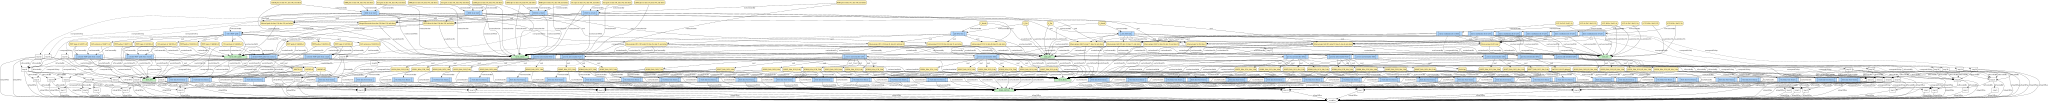

In [3]:
graph_file = Path(output_path, "prov_full") 
dot_prov_full = draw_prov_full(roc_graph)
dot_prov_full.render(graph_file, format="png")
display(dot_prov_full)

## Retrospective provenance
The second graph shows retrospective provenance (prov-o).
The activities (blue boxes), entities (yellow pillboxes), and agents (green pentagons) are the retrospective provenance, i.e. the workflow run.

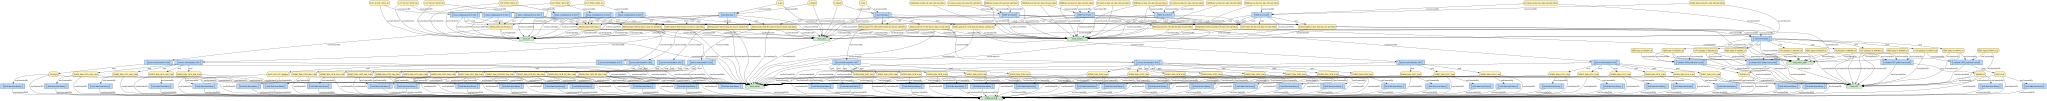

In [4]:
graph_file = Path(output_path, "prov_only") 
prov_dot = draw_prov_only(roc_graph)
prov_dot.render(graph_file, format="png")
display(prov_dot)

## Full provenance
The third graph shows the prospective (p-plan).
Workflow (white ellipse) and workflow steps (white boxes) are the prospective provenance, i.e. the workflow, to make it more understandable the graph also includes the PROV-O activities corresponding to each step (blue boxes).

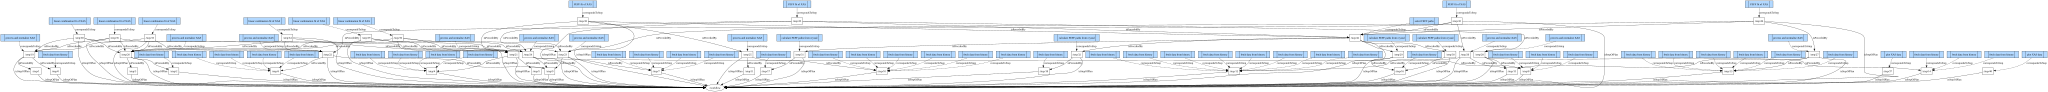

In [5]:
graph_file = Path(output_path, "pplan_only") 

plan_dot = draw_pplan_only(roc_graph)
plan_dot.render(graph_file, format="png")
display(plan_dot)

# Present provenance in table
We need to build a table from the RDF graph. The table shows the activity, the agent, the resulting dataset and the inputs that helped creating it.

activity -> agent/tool -> Entity (dataset) -> inputs 


In [6]:
datasets_prov = get_datasets_prov(roc_graph)
display(HTML(datasets_prov.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,Sn foil.prj,None
1,/step/10,fetch data from history,DATA_FETCH,263929_PtSn_OCH_1.dat,None
2,/step/10,fetch data from history,DATA_FETCH,263930_PtSn_OCH_2.dat,None
3,/step/10,fetch data from history,DATA_FETCH,263931_PtSn_OCH_3.dat,None
4,/step/10,fetch data from history,DATA_FETCH,263932_PtSn_OCH_4.dat,None
5,/step/10,fetch data from history,DATA_FETCH,263933_PtSn_OCH_5.dat,None
6,/step/10,fetch data from history,DATA_FETCH,263934_PtSn_OCH_6.dat,None
7,/step/12,fetch data from history,DATA_FETCH,263824_PtSn_OCH_1.dat,None
8,/step/12,fetch data from history,DATA_FETCH,263825_PtSn_OCH_2.dat,None
9,/step/12,fetch data from history,DATA_FETCH,263826_PtSn_OCH_3.dat,None


# Datasets in Detail
Using the PROV-O file, we can get the details of each dataset and display them in a user friendly way


In [7]:
ds_jsons = show_datasets(roc_graph, file_path, output_path)

,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,application/vnd.demeter.athena
4,dcterms:description,atsym: Nonebkg_e0: 29200edge: Nonenpts: 2094xmax: 30049.25xmin: 29000.24
5,schema:id,datasets/Sn_foil.prj_b9b199e627b0df6d.prj
6,skos:prefLabel,Sn foil.prj
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/263929_PtSn_OCH_1.dat_c1b1e33af4bbfb98.tabular
6,skos:prefLabel,263929_PtSn_OCH_1.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/263930_PtSn_OCH_2.dat_2dce3cba98f791fe.tabular
6,skos:prefLabel,263930_PtSn_OCH_2.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/263931_PtSn_OCH_3.dat_c289466c92d2c272.tabular
6,skos:prefLabel,263931_PtSn_OCH_3.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/263932_PtSn_OCH_4.dat_8392e1ce86b3f444.tabular
6,skos:prefLabel,263932_PtSn_OCH_4.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


...

,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/262880_PtSn_OCA_Abu_3.dat_c2de473dd283bcf1.tabular
6,skos:prefLabel,262880_PtSn_OCA_Abu_3.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/262881_PtSn_OCA_Abu_4.dat_db463272d57e0530.tabular
6,skos:prefLabel,262881_PtSn_OCA_Abu_4.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/262875_PtSn_OCO_Abu_1.dat_a2ddc3fedfe1b725.tabular
6,skos:prefLabel,262875_PtSn_OCO_Abu_1.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/262876_PtSn_OCO_Abu_2.dat_4788d985a9c586e4.tabular
6,skos:prefLabel,262876_PtSn_OCO_Abu_2.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,cdifprov:Dataset
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,dcterms:description,uploaded tabular file
5,schema:id,datasets/262877_PtSn_OCO_Abu_3.dat_0130dc9d5e228c18.tabular
6,skos:prefLabel,262877_PtSn_OCO_Abu_3.dat
7,prov:wasGeneratedBy,fetch data from history
8,prov:wasAttributedTo,DATA_FETCH
9,prov:wasAttributedTo,larch_athena


## Save provenance into RO-Crate

Using the ROCrate library to add new entities to the RO-Crate

In [8]:
from rocrate.rocrate import ROCrate

crate = ROCrate(file_path)

#print (f"The crate {file_path} has {len(crate.data_entities)} entities")
#print(list(Path(output_path).iterdir()))
#print(dir(crate))

prov_file = "galaxy_run_prov.jsonld"

prov_file_ttl = "galaxy_run_prov.ttl"

diagram = crate.add_file(Path(output_path,prov_file), dest_path=f"provenance/{prov_file}", properties={
    "name": "Provenance of Galaxy RO Crate",
    "encodingFormat": "application/json"
})

diagram = crate.add_file(Path(output_path,prov_file_ttl), dest_path=f"provenance/{prov_file_ttl}", properties={
    "name": "Provenance of Galaxy RO Crate",
    "encodingFormat": "text/turtle"
})

for a_file in ds_jsons:
    # saving to provenance path inside the ro-crate
    diagram = crate.add_file(Path(output_path,a_file), dest_path=f"provenance/{a_file}", properties={
    "name": f"Details of dataset /{a_file.replace('_','/').replace('.jsonld','')}",
    "encodingFormat": "application/json"})

modified_rocrates = Path("./result_roc")
name_roc_out = file_path.name[:-4]+".prov.zip"
result = crate.write_zip(Path(modified_rocrates, name_roc_out))

#print (f"The crate {file_path} has now {len(crate.data_entities)} entities")


C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Ready to publish RO-Crate

At this stage we can publish the RO-Crate and the discovery metadata we have. This includes
 - provenance of each dataset consumed or generated
 - metadata about each dataset
 - Identify XAS datasets (fes2_rt01_mar02.xmu, FeS2_athena, fit_report_FeS2). 

More advanced processing would entail also looking at tool parameters, so there is better understanding of the details of the provenance chain, if needed.